In [65]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 訓練データを読み込みます
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size = (75,75),
    label_mode = "binary",
    batch_size = 32,
    shuffle = False
)

# テストデータも同様に読み込みます
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(75, 75),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

# 読み込んだクラス名（フォルダ名）を確認します
class_names = train_dataset.class_names
print("クラス名:", class_names)

Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
クラス名: ['cat', 'dog']


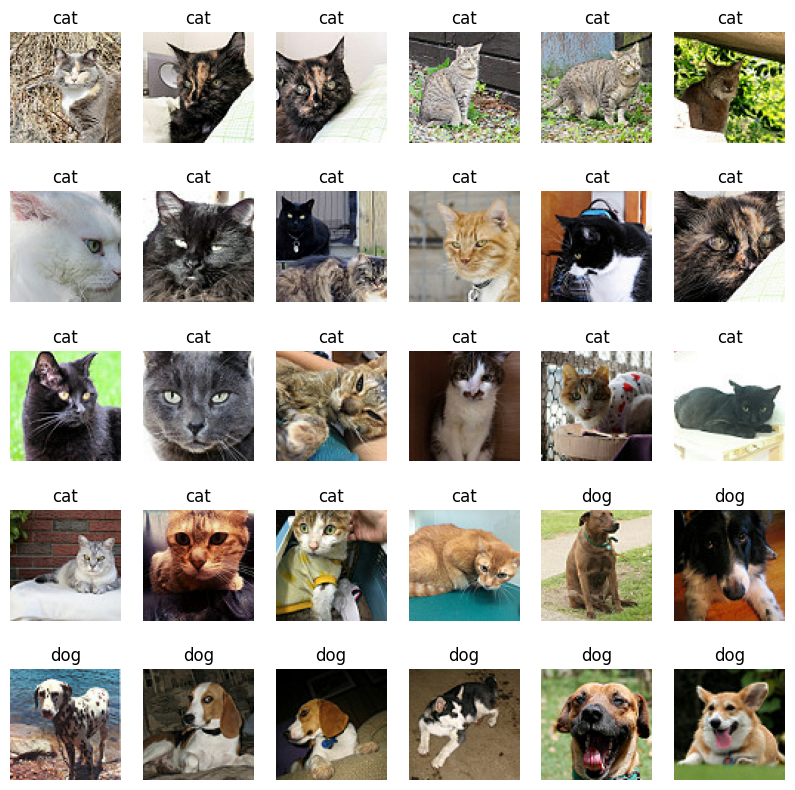

In [66]:
# データセットを高速化します
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# データの中身を見てみましょう
plt.figure(figsize = (10,10))
for images, labels in train_dataset.take(1):
    for i in range(30):
        ax = plt.subplot(5,6,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

#画像表示
plt.show()

In [67]:
# データの前処理レイヤーを作成
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# Googleが学習済みのモデル（MobileNetV2）を土台として読み込みます
# include_top = Falseは、最終層（1000クラス分類）を含めない設定
base_model = tf.keras.applications.MobileNetV2(input_shape=(75,75,3),
                                               include_top=False,
                                               weights='imagenet'
                                               )

# 土台となるモデルの重み「凍結」して、学習で更新されないようにします
base_model.trainable = False

# 新しい出力層を独自に追加します
inputs = tf.keras.Input(shape=(75,75,3))
x = preprocess_input(inputs) # データをモデルが好む形式に前処理
x = base_model(x,training =False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(1)(x) # 最終的な出力は1つ（yesかnoか）
model = tf.keras.Model(inputs,x)

/var/folders/cc/9lwsz28j0glcyvmpst59f7dm0000gn/T/ipykernel_67871/2866253226.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=(75,75,3),


In [68]:
# モデルをコンパイルします
model.compile(optimizer='adam',
              loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

# モデルの構造を確認します
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 75, 75, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_8 (TrueDivide)      │ (None, 75, 75, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_8 (Subtract)           │ (None, 75, 75, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [69]:
# モデルの学習を開始します
history = model.fit(
    train_dataset,
    epochs = 10,
    validation_data = test_dataset
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.6433 - loss: 0.9173 - val_accuracy: 0.7800 - val_loss: 0.5913
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7200 - loss: 0.7037 - val_accuracy: 0.8200 - val_loss: 0.4538
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8567 - loss: 0.3397 - val_accuracy: 0.8900 - val_loss: 0.2280
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8667 - loss: 0.2839 - val_accuracy: 0.9000 - val_loss: 0.1927
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8967 - loss: 0.2129 - val_accuracy: 0.9400 - val_loss: 0.1727
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9167 - loss: 0.1888 - val_accuracy: 0.9500 - val_loss: 0.1759
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9100 - loss: 0.1702 - val_accuracy: 0.9400 - val_loss: 0.1446
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9167 - loss: 0.1455 - val_accuracy: 0.9500 - v

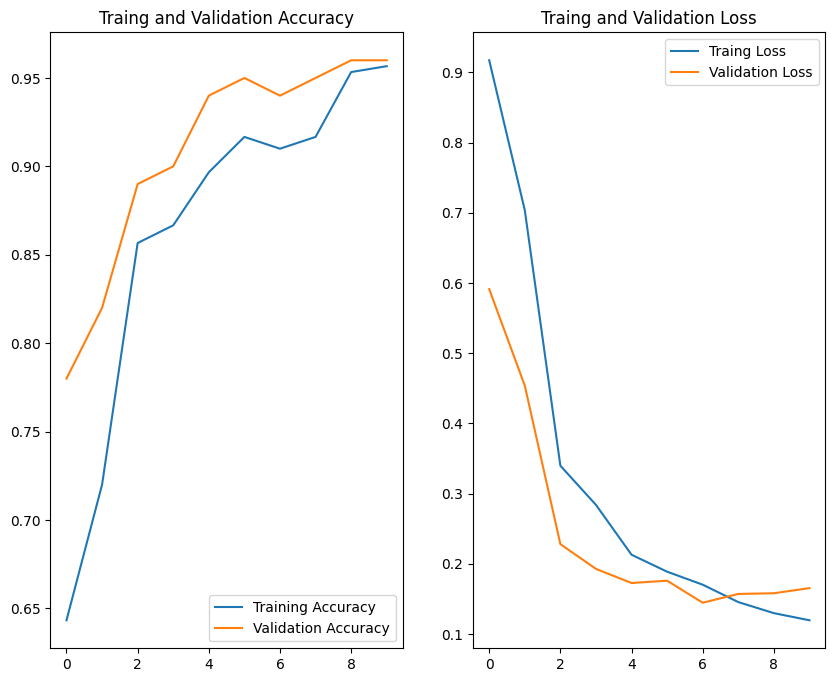

In [70]:
# 学習の結果をプロットします。
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(10)

plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.plot(epochs_range,acc,label='Training Accuracy')
plt.plot(epochs_range,val_acc,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Traing and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,loss,label='Traing Loss')
plt.plot(epochs_range,val_loss,label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Traing and Validation Loss')
plt.show()


In [71]:
# evaluate()でモデルの性能を評価する
loss,accuracy = model.evaluate(test_dataset)

print(f"\nテストデータの最終正解率は(Accuracy:{accuracy * 100:0.2f}%)")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9600 - loss: 0.1654

テストデータの最終正解率は(Accuracy:96.00%)
